# Medical CNN (adapted from satellite_CNN.ipynb)

This notebook reuses the model, augmentation and training pipeline from `satellite_CNN.ipynb` and adapts it to the `datasets/skin_cancer` dataset.

Cells are organized so you can run top-to-bottom: data preparation, generators, model helpers, short sanity training, and evaluation.

If image filenames use an extension other than `.jpg`, update the filename construction in cell 2.

images dir: C:\Users\Pc\Desktop\deep_learning\datasets\skin_cancer\train-image\image
metadata: C:\Users\Pc\Desktop\deep_learning\datasets\skin_cancer\train-metadata.csv
Previewing augmented images for minority class: malignant
Previewing augmented images for minority class: malignant


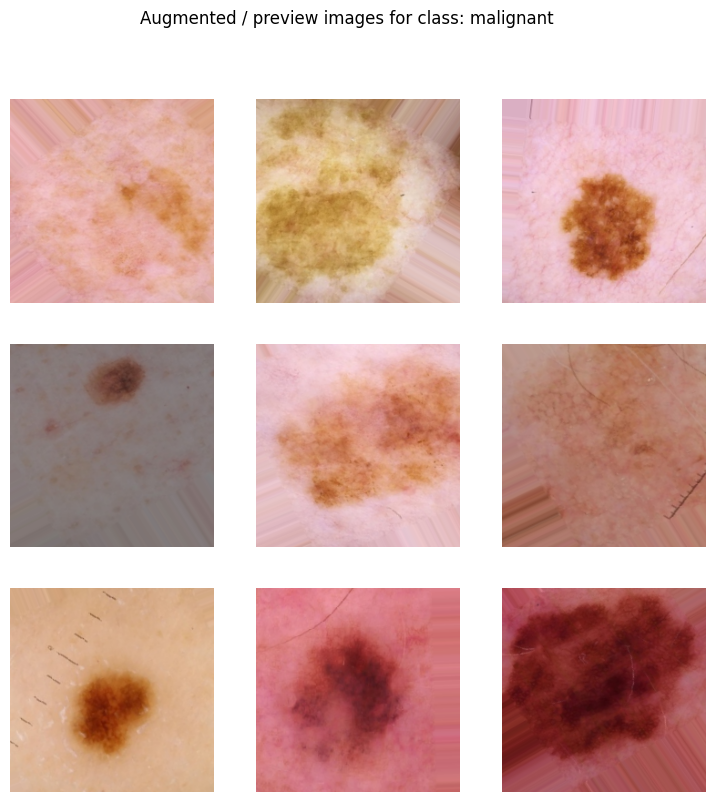

In [30]:
# Cell 2: imports and paths
import os
import shutil
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL

# Paths - change BASE if your workspace is elsewhere
BASE = r'C:\Users\Pc\Desktop\deep_learning'
SKIN_ROOT = os.path.join(BASE, 'datasets', 'skin_cancer')
IMAGES_DIR = os.path.join(SKIN_ROOT, 'train-image', 'image')
METADATA = os.path.join(SKIN_ROOT, 'train-metadata.csv')
# Working train/test directories we will create
TRAIN_DIR = os.path.join(SKIN_ROOT, 'working_medical_cnn', 'training')
TEST_DIR = os.path.join(SKIN_ROOT, 'working_medical_cnn', 'testing')
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)
print('images dir:', IMAGES_DIR)
print('metadata:', METADATA)
# Configuration flags - tweak these before running
AUGMENT_ON_DISK = True  # perform on-disk augmentation of minority class to balance
# prefix used for on-disk augmented files (used later to identify augmented files)
AUGMENT_PREFIX = 'aug_'
# Test-set augmentation flags (use with caution; test sets are normally not augmented)
AUGMENT_TEST_ON_DISK = False  # set True to generate augmented test images
AUGMENT_TEST_PREFIX = 'taug_'
AUGMENT_TEST_MAX_PER_IMAGE = 2

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# determine minority class directory as in augmentation cell
class_dirs = {l: os.path.join(TRAIN_DIR, l) for l in ['benign', 'malignant']}
counts = {l: len([f for f in os.listdir(d) if os.path.isfile(os.path.join(d,f)) and not f.startswith(globals().get('AUGMENT_PREFIX','aug_'))]) if os.path.isdir(d) else 0 for l,d in class_dirs.items()}
minority_label = min(counts, key=counts.get)
minority_dir = class_dirs[minority_label]
print('Previewing augmented images for minority class:', minority_label)

n_cols = 3
n_rows = 3
total = n_cols * n_rows
imgs = []

if globals().get('AUGMENT_ON_DISK', True) and os.path.isdir(minority_dir):
    aug_files = [f for f in os.listdir(minority_dir) if os.path.isfile(os.path.join(minority_dir, f)) and f.startswith(globals().get('AUGMENT_PREFIX', 'aug_'))]
    if len(aug_files) > 0:
        sel = aug_files[:total]
        for f in sel:
            p = os.path.join(minority_dir, f)
            try:
                img = load_img(p, target_size=INPUT_SHAPE[:2])
                arr = img_to_array(img).astype('uint8')
                imgs.append(arr)
            except Exception as e:
                print('failed loading', p, e)
    else:
        originals = [f for f in os.listdir(minority_dir) if os.path.isfile(os.path.join(minority_dir,f)) and not f.startswith(globals().get('AUGMENT_PREFIX','aug_'))] if os.path.isdir(minority_dir) else []
        if len(originals) == 0:
            print('No originals available to preview')
        else:
            aug = ImageDataGenerator(rotation_range=40, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.15, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest')
            idx = 0
            while len(imgs) < total:
                orig = originals[idx % len(originals)]
                idx += 1
                p = os.path.join(minority_dir, orig)
                try:
                    img = load_img(p, target_size=INPUT_SHAPE[:2])
                    x = img_to_array(img).reshape((1,)+img_to_array(img).shape)
                    it = aug.flow(x, batch_size=1)
                    batch = next(it)
                    arr = batch[0].astype('uint8')
                    imgs.append(arr)
                except Exception as e:
                    print('preview generation failed for', p, e); continue

else:
    originals = [f for f in os.listdir(minority_dir) if os.path.isfile(os.path.join(minority_dir,f))] if os.path.isdir(minority_dir) else []
    if len(originals) == 0:
        print('No images available to preview in', minority_dir)
    else:
        aug = ImageDataGenerator(rotation_range=40, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.15, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest')
        idx = 0
        while len(imgs) < total:
            orig = originals[idx % len(originals)]
            idx += 1
            p = os.path.join(minority_dir, orig)
            try:
                img = load_img(p, target_size=INPUT_SHAPE[:2])
                x = img_to_array(img).reshape((1,)+img_to_array(img).shape)
                it = aug.flow(x, batch_size=1)
                batch = next(it)
                arr = batch[0].astype('uint8')
                imgs.append(arr)
            except Exception as e:
                print('preview generation failed for', p, e); continue

if len(imgs) == 0:
    print('No preview images generated')
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
    axes = axes.flatten()
    for ax, im in zip(axes, imgs):
        ax.imshow(im.astype('uint8'))
        ax.axis('off')
    for ax in axes[len(imgs):]:
        ax.axis('off')
    plt.suptitle(f'Augmented / preview images for class: {minority_label}')
    plt.show()

In [31]:
# Cell 4: ImageDataGenerators and directory iterators (augmentation similar to satellite notebook)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 2
CLASS_MODE = 'categorical'
VALIDATION_SPLIT = 0.1

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
    validation_split=VALIDATION_SPLIT,
)

train_generator = train_gen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    subset='training',
    color_mode='rgb',
    shuffle=True,
    seed=42,
)

valid_generator = train_gen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    subset='validation',
    color_mode='rgb',
    shuffle=False,
    seed=42,
)

test_gen = ImageDataGenerator(rescale=1./255)
test_generator = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    color_mode='rgb',
    shuffle=False,
    seed=42,
)

print('class indices:', train_generator.class_indices)
# If augmentation ran and you fully balanced the dataset, you may set USE_CLASS_WEIGHT=False before training
print('AUGMENT_ON_DISK =', globals().get('AUGMENT_ON_DISK', False), 'USE_CLASS_WEIGHT =', globals().get('USE_CLASS_WEIGHT', True))

Found 23851 images belonging to 2 classes.
Found 2649 images belonging to 2 classes.
Found 2649 images belonging to 2 classes.
Found 6626 images belonging to 2 classes.
Found 6626 images belonging to 2 classes.
class indices: {'benign': 0, 'malignant': 1}
AUGMENT_ON_DISK = True USE_CLASS_WEIGHT = True
class indices: {'benign': 0, 'malignant': 1}
AUGMENT_ON_DISK = True USE_CLASS_WEIGHT = True


In [32]:
# Cell 5: model helpers (compile_model, plot_history, display_results)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, fbeta_score, accuracy_score

def compile_model(cnn_base, input_shape, n_classes, optimizer, fine_tune=None):
    if cnn_base == 'ResNet50':
        conv_base = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
        top_model = conv_base.output
        top_model = Flatten()(top_model)
        top_model = Dense(1024, activation='relu')(top_model)
        top_model = Dropout(0.3)(top_model)
    output_layer = Dense(n_classes, activation='softmax')(top_model)
    model = Model(inputs=conv_base.input, outputs=output_layer)
    if type(fine_tune) == int:
        for layer in conv_base.layers[fine_tune:]:
            layer.trainable = True
    else:
        for layer in conv_base.layers:
            layer.trainable = False
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['categorical_accuracy'])
    return model

def plot_history(history):
    acc = history.history.get('categorical_accuracy', [])
    val_acc = history.history.get('val_categorical_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(acc); plt.plot(val_acc)
    plt.title('accuracy'); plt.legend(['train','val'])
    plt.subplot(1,2,2)
    plt.plot(loss); plt.plot(val_loss)
    plt.title('loss'); plt.legend(['train','val'])
    plt.show()

def display_results(y_true, y_preds, class_labels):
    results = pd.DataFrame(precision_recall_fscore_support(y_true, y_preds), columns=class_labels).T
    results.rename(columns={0:'Precision',1:'Recall',2:'F-Score',3:'Support'}, inplace=True)
    conf_mat = pd.DataFrame(confusion_matrix(y_true, y_preds), columns=class_labels, index=class_labels)
    f2 = fbeta_score(y_true, y_preds, beta=2, average='micro')
    accuracy = accuracy_score(y_true, y_preds)
    print(f'Accuracy: {accuracy}')
    print(f'Global F2 Score: {f2}')
    return results, conf_mat

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 126,351,234 (481.99 MB)

 Trainable params: 102,763,522 (392.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

...

208/208 ━━━━━━━━━━━━━━━━━━━━ 186s 887ms/step
208/208 ━━━━━━━━━━━━━━━━━━━━ 186s 887ms/step


c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Accuracy: 0.9823422879565349
Global F2 Score: 0.9823422879565349
           Precision  Recall   F-Score  Support
benign      0.982342     1.0  0.991093   6509.0
malignant   0.000000     0.0  0.000000    117.0
USE_CLASS_WEIGHT is True — wrapping train_generator to emit sample weights (not passing class_weight to fit)
Epoch 1/3
Epoch 1/3
745/745 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.5319 - loss: 0.7223
Epoch 1: val_categorical_accuracy improved from -inf to 0.01601, saving model to model.weights.best.keras

Epoch 1: val_categorical_accuracy improved from -inf to 0.01601, saving model to model.weights.best.keras
745/745 ━━━━━━━━━━━━━━━━━━━━ 1242s 2s/step - categorical_accuracy: 0.5318 - loss: 0.7223 - val_categorical_accuracy: 0.0160 - val_loss: 0.6990 - learning_rate: 1.0000e-04
Epoch 2/3
745/745 ━━━━━━━━━━━━━━━━━━━━ 1242s 2s/step - categorical_accuracy: 0.5318 - loss: 0.7223 - val_categorical_accuracy: 0.0160 - val_loss: 0.6990 - learning_rate: 1.0000e-04
Epoch 2/3
 

c:\Python311\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)



Epoch 2: val_categorical_accuracy improved from 0.01601 to 0.96000, saving model to model.weights.best.keras
745/745 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - categorical_accuracy: 0.0000e+00 - loss: 0.3568 - val_categorical_accuracy: 0.9600 - val_loss: 0.7149 - learning_rate: 1.0000e-04
Epoch 3/3
745/745 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - categorical_accuracy: 0.0000e+00 - loss: 0.3568 - val_categorical_accuracy: 0.9600 - val_loss: 0.7149 - learning_rate: 1.0000e-04
Epoch 3/3
745/745 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.2095 - loss: 0.6796
Epoch 3: val_categorical_accuracy did not improve from 0.96000
745/745 ━━━━━━━━━━━━━━━━━━━━ 1223s 2s/step - categorical_accuracy: 0.2095 - loss: 0.6796 - val_categorical_accuracy: 0.0248 - val_loss: 0.6997 - learning_rate: 1.0000e-04

Epoch 3: val_categorical_accuracy did not improve from 0.96000
745/745 ━━━━━━━━━━━━━━━━━━━━ 1223s 2s/step - categorical_accuracy: 0.2095 - loss: 0.6796 - val_categorical_accuracy: 0.0248 - val_loss: 

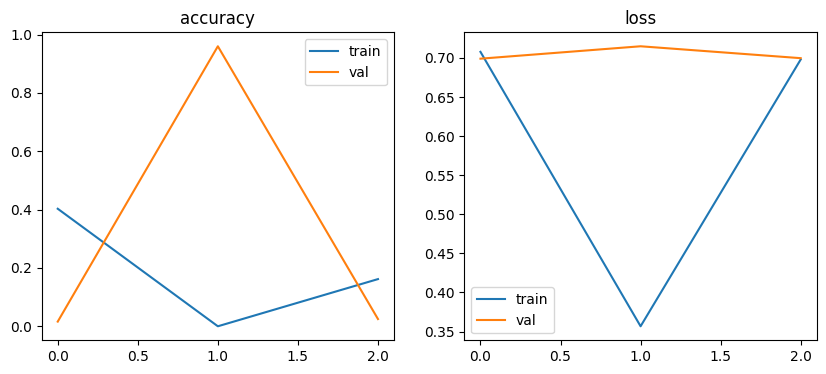

In [33]:
# Cell 6: GPU config, callbacks and short sanity training run
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
    print('using GPU')
  except RuntimeError as e:
    print(e)

checkpoint = ModelCheckpoint(filepath=os.path.join('model.weights.best.keras'), monitor='val_categorical_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_categorical_accuracy', patience=6, restore_best_weights=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_categorical_accuracy', factor=0.5, patience=3, min_lr=1e-6)

N_STEPS = max(1, train_generator.samples // BATCH_SIZE)
N_VAL_STEPS = max(1, valid_generator.samples // BATCH_SIZE)
N_EPOCHS = 3  # short run for sanity; increase for full training

model = compile_model('ResNet50', INPUT_SHAPE, NUM_CLASSES, Adam(learning_rate=1e-4), fine_tune=None)
model.summary()

# Cell X: Balance TEST_DIR (optional) and run evaluation immediately after balancing
if globals().get('AUGMENT_TEST_ON_DISK', False):
    print('AUGMENT_TEST_ON_DISK is True — balancing TEST_DIR via on-disk augmentation')
    # Balance test set similar to training augmentation but with smaller cap
    from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
    class_dirs_test = {l: os.path.join(TEST_DIR, l) for l in ['benign', 'malignant']}
    counts_test = {}
    for l,d in class_dirs_test.items():
        if os.path.isdir(d):
            counts_test[l] = len([f for f in os.listdir(d) if os.path.isfile(os.path.join(d,f)) and not f.startswith(globals().get('AUGMENT_TEST_PREFIX','taug_'))])
        else:
            counts_test[l] = 0
    print('current test counts (originals):', counts_test)
    maj = max(counts_test.values())
    minor = min(counts_test, key=counts_test.get)
    need = maj - counts_test[minor]
    if need <= 0:
        print('Test set already balanced (w.r.t. original files)')
    else:
        print(f'Augmenting {need} test images for class: {minor}')
        aug_test = ImageDataGenerator(rotation_range=25, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')
        minority_dir_test = class_dirs_test[minor]
        originals_test = [f for f in os.listdir(minority_dir_test) if os.path.isfile(os.path.join(minority_dir_test,f)) and not f.startswith(globals().get('AUGMENT_TEST_PREFIX','taug_'))]
        if len(originals_test) == 0:
            print('No originals in test minority dir to augment')
        else:
            gen = 0
            idx_test = 0
            cap_test = min(need, maj * globals().get('AUGMENT_TEST_MAX_PER_IMAGE',2))
            from tqdm import trange
            pbar = trange(cap_test, desc='generating test augmented images')
            while gen < cap_test:
                orig = originals_test[idx_test % len(originals_test)]
                idx_test += 1
                pth = os.path.join(minority_dir_test, orig)
                try:
                    img_t = load_img(pth, target_size=INPUT_SHAPE[:2])
                except Exception as e:
                    print('failed loading', pth, e); continue
                xx = img_to_array(img_t).reshape((1,)+img_to_array(img_t).shape)
                pref = f"{globals().get('AUGMENT_TEST_PREFIX','taug_')}{os.path.splitext(orig)[0]}"
                it = aug_test.flow(xx, batch_size=1, save_to_dir=minority_dir_test, save_prefix=pref, save_format='jpg')
                try:
                    next(it)
                    gen += 1
                    pbar.update(1)
                except StopIteration:
                    pass
            pbar.close()
            print('Generated', gen, 'test augmented images for', minor)
            # show new test counts
            new_counts_test = {l: len([f for f in os.listdir(d) if os.path.isfile(os.path.join(d,f))]) if os.path.isdir(d) else 0 for l,d in class_dirs_test.items()}
            print('new test counts (including generated files):', new_counts_test)

# After optional balancing, run evaluation (same as Cell 7) — this will load best weights and compute metrics
print('Running evaluation on TEST_DIR...')
if not os.path.isdir(TEST_DIR) or sum([len(files) for r,d,files in os.walk(TEST_DIR)]) == 0:
    print('TEST_DIR is empty — ensure copy step completed or run Cell 3 to create TEST_DIR')
else:
    try:
        model.load_weights('model.weights.best.keras')
    except Exception as e:
        print('Failed to load weights:', e)
    test_paths = []
    for cls in os.listdir(TEST_DIR):
        cls_dir = os.path.join(TEST_DIR, cls)
        if os.path.isdir(cls_dir):
            for f in os.listdir(cls_dir):
                if f.lower().endswith(('.jpg','.png','.jpeg')):
                    test_paths.append((os.path.join(cls_dir,f), cls))
    X_list = []
    y_true = []
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    for p, cls in test_paths:
        try:
            img = load_img(p, target_size=INPUT_SHAPE[:2])
            arr = img_to_array(img)/255.0
            X_list.append(arr)
            y_true.append(0 if cls=='benign' else 1)
        except Exception as e:
            print('failed loading test image', p, e)
    if len(X_list) > 0:
        X_test = np.stack(X_list)
        preds = model.predict(X_test, batch_size=32, verbose=1)
        pred_classes = np.argmax(preds, axis=1)
        class_labels = ['benign','malignant']
        prf, conf = display_results(y_true, pred_classes, class_labels)
        print(prf)
    else:
        print('no test images found; make sure the copy step completed and files exist')
# Compute class_weight_dict if not already defined
# Prefer counts (from earlier cell) and train_generator.class_indices mapping.
if 'class_weight_dict' not in globals():
    try:
        if 'counts' in globals() and isinstance(counts, dict) and 'train_generator' in globals():
            mapping = train_generator.class_indices  # e.g. {'benign':0, 'malignant':1}
            total = sum(counts.values()) if sum(counts.values()) > 0 else 1
            # create weights inversely proportional to class frequency (normalized by number of classes)
            class_weight_dict = {mapping[label]: total / (len(counts) * max(1, cnt)) for label, cnt in counts.items()}
        elif 'train_generator' in globals() and hasattr(train_generator, 'classes'):
            unique, cnts = np.unique(train_generator.classes, return_counts=True)
            class_weight_dict = {int(u): float(sum(cnts)) / (len(cnts) * max(1, int(c))) for u, c in zip(unique, cnts)}
        else:
            class_weight_dict = None
    except Exception as e:
        print('failed to compute class_weight_dict:', e)
        class_weight_dict = None

# Workaround: some TF versions wrap Sequence into a Dataset when class_weight is provided,
# expecting the generator to yield (x, y, sample_weight). DirectoryIterator yields (x,y),
# causing the "expected structure length 3" error. To be robust we will:
# - If class weighting is requested, wrap the DirectoryIterator with a Sequence that yields (x, y, sample_weight)
# - Do NOT pass class_weight to model.fit in that case (we already applied weights via the generator)
from tensorflow.keras.utils import Sequence as KerasSequence

class WeightedDirectoryIterator(KerasSequence):
    """Wrap a DirectoryIterator (or any Sequence yielding (x, y)) and append sample weights per batch."""
    def __init__(self, directory_iterator, class_weight):
        self.it = directory_iterator
        self.class_weight = class_weight or {}
    def __len__(self):
        return len(self.it)
    def __getitem__(self, idx):
        batch = self.it[idx]  # expected (x_batch, y_batch)
        if isinstance(batch, tuple) and len(batch) >= 2:
            x_batch, y_batch = batch[0], batch[1]
        else:
            # unexpected structure — just forward
            return batch
        # y_batch expected one-hot; compute class indices per sample
        cls_idx = np.argmax(y_batch, axis=1) if y_batch.ndim == 2 else np.array(y_batch, dtype=int)
        sample_weights = np.array([float(self.class_weight.get(int(c), 1.0)) for c in cls_idx], dtype=np.float32)
        return x_batch, y_batch, sample_weights
    def on_epoch_end(self):
        # propagate to underlying iterator (useful if it shuffles)
        if hasattr(self.it, 'on_epoch_end'):
            self.it.on_epoch_end()

# Decide whether to use wrapped generator to emit sample weights
use_class_weight = globals().get('USE_CLASS_WEIGHT', True)
train_input = train_generator
fit_class_weight = None

if use_class_weight and class_weight_dict:
    # Wrap the generator to emit (x, y, sample_weight) to avoid TF expecting to add sample_weight itself
    train_input = WeightedDirectoryIterator(train_generator, class_weight_dict)
    fit_class_weight = None  # we already provide sample_weight via the Sequence
    print('USE_CLASS_WEIGHT is True — wrapping train_generator to emit sample weights (not passing class_weight to fit)')
else:
    fit_class_weight = None
    if not use_class_weight:
        print('USE_CLASS_WEIGHT is False — training without class weights')
    else:
        print('No class_weight_dict available — training without class weights')

history = model.fit(
    train_input,
    steps_per_epoch=N_STEPS,
    epochs=N_EPOCHS,
    validation_data=valid_generator,
    validation_steps=N_VAL_STEPS,
    callbacks=[early_stop, checkpoint, reduce_lr],
    class_weight=fit_class_weight,  # None because we either wrapped generator or disabled class weights
)
plot_history(history)

In [34]:
# Cell 7: Evaluation on test set (assemble images into array and predict)
model.load_weights('model.weights.best.keras')
test_paths = []
for cls in os.listdir(TEST_DIR):
    cls_dir = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cls_dir):
        for f in os.listdir(cls_dir):
            if f.lower().endswith(('.jpg','.png','.jpeg')):
                test_paths.append((os.path.join(cls_dir,f), cls))

X_list = []
y_true = []
from tensorflow.keras.preprocessing.image import load_img, img_to_array
for p, cls in test_paths:
    img = load_img(p, target_size=INPUT_SHAPE[:2])
    arr = img_to_array(img)/255.0
    X_list.append(arr)
    y_true.append(0 if cls=='benign' else 1)
if len(X_list) > 0:
    X_test = np.stack(X_list)
    preds = model.predict(X_test, batch_size=32, verbose=1)
    pred_classes = np.argmax(preds, axis=1)
    class_labels = ['benign','malignant']
    prf, conf = display_results(y_true, pred_classes, class_labels)
    prf
else:
    print('no test images found; make sure the copy step completed and files exist')

208/208 ━━━━━━━━━━━━━━━━━━━━ 182s 873ms/step
208/208 ━━━━━━━━━━━━━━━━━━━━ 182s 873ms/step
Accuracy: 0.03712647147600362
Global F2 Score: 0.03712647147600362
Accuracy: 0.03712647147600362
Global F2 Score: 0.03712647147600362


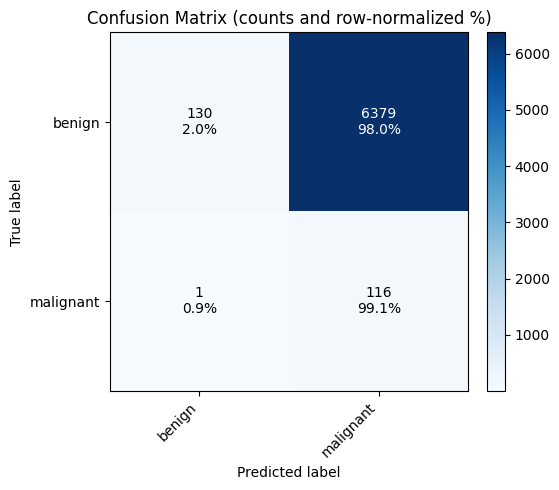

,benign,malignant
benign,130,6379
malignant,1,116


In [35]:
# Plot confusion matrix (counts + row-normalized percentages)
if 'pred_classes' in globals() and 'y_true' in globals() and len(y_true) > 0:
    cm = confusion_matrix(y_true, pred_classes)
    labels = globals().get('class_labels', [str(i) for i in range(cm.shape[0])])
    # row-normalized (per true class) to show recall-like percentages
    with np.errstate(all='ignore'):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    ax.set_title('Confusion Matrix (counts and row-normalized %)')

    # annotate cells with count and percentage
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            pct = cm_norm[i, j] * 100.0
            text = f"{count}\n{pct:.1f}%"
            ax.text(j, i, text, ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

    # also print the computed matrix as a DataFrame for convenience
    try:
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)
        display(cm_df)
    except Exception:
        print(cm)
else:
    print("pred_classes or y_true not found / empty — cannot compute confusion matrix.")